PART A: SURVEY AND SAMPLING

Practical 7: Sampling and Sampling Distributions

First Five Records:
            Timestamp             1. Name  \
0  9/19/2026 22:30:54                Azma   
1  9/19/2026 22:45:29        Leena Mondal   
2  9/19/2026 22:55:44  Santosh prajapati    
3  9/19/2026 23:08:32            Radhika    
4  9/19/2026 23:14:59                 Sid   

  2. Which area/locality do you live in?  \
0                       Santacruz (east)   
1                             Bhayandar    
2                          Naigaon east    
3                          Andheri East    
4                    Santacruz/ Andheri    

  3. How many people are there in your household?  \
0                                              52   
1                                               4   
2                                             180   
3                                               4   
4                                               3   

  4. Approximately how much waste does your household generate per day? (in kg)  \
0                                         

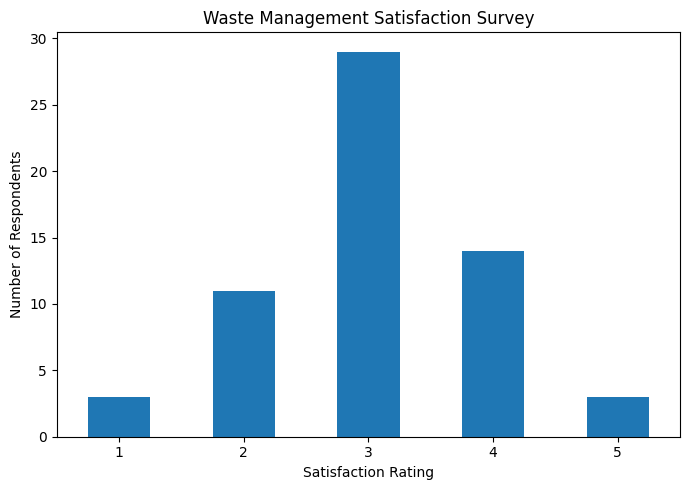

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("Waste Management Survey Responses - Form Responses 1.csv")

# Display first five records
print("First Five Records:")
print(df.head()) 

# Display number of responses
print("\nTotal Number of Responses:", len(df))

# Select numerical variable
# --------------------------------------------------

#Satisfaction with waste management
column = "9. How satisfied are you with waste management in your area?"

satisfaction = pd.to_numeric(df[column], errors="coerce").dropna()

#  Calculate statistics
sample_size = len(satisfaction)
mean_value = satisfaction.mean()
median_value = satisfaction.median()
std_value = satisfaction.std()

print("\nStatistics:")
print("Sample Size:", sample_size)
print("Mean:", round(mean_value, 2))
print("Median:", round(median_value, 2))
print("Standard Deviation:", round(std_value, 2))

# Display frequency of satisfaction ratings
print("\nSatisfaction Frequency:")
print(satisfaction.value_counts().sort_index())

# Create suitable chart
plt.figure(figsize=(7,5))

satisfaction.value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Waste Management Satisfaction Survey")
plt.xlabel("Satisfaction Rating")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 PART B: SAMPLING DISTRIBUTION



Random Sample of 30:
0     2
5     4
36    5
45    3
13    2
54    1
33    3
48    4
12    3
57    2
46    3
50    3
31    3
3     3
52    3
17    2
8     4
6     3
40    4
4     3
43    1
19    2
34    4
58    4
25    1
56    3
15    3
27    2
9     5
30    3
Name: 9. How satisfied are you with waste management in your area?, dtype: int64

Mean of Selected Sample: 2.93

First 10 Sample Means:
   Sample Number  Sample Mean
0              1     2.933333
1              2     3.100000
2              3     3.066667
3              4     2.966667
4              5     3.100000
5              6     3.133333
6              7     2.933333
7              8     2.900000
8              9     3.066667
9             10     2.900000

Mean of All Sample Means: 3.049
Standard Deviation of Sample Means: 0.105


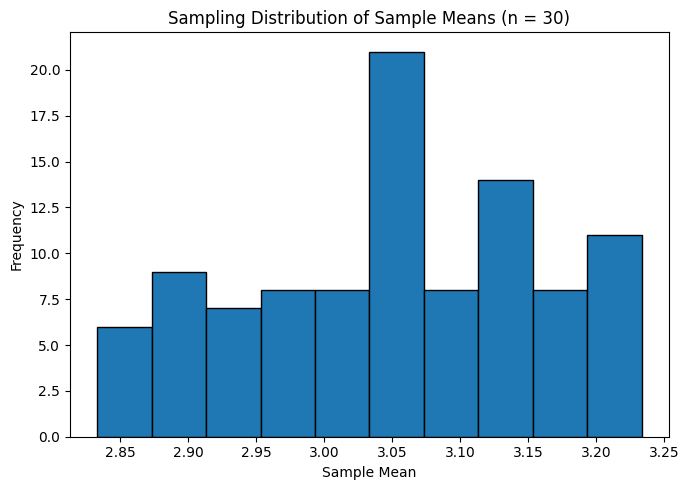


Standard Error: 0.166

Comparison:
Original Sample Mean: 3.05
Mean of Sampling Distribution: 3.049

Comparison of Different Sample Sizes:
   Sample Size  Mean of Sample Means  SD of Sample Means
0           10                 3.052               0.255
1           20                 3.046               0.160
2           30                 3.049               0.130
3           40                 3.042               0.080

Estimated Population Mean: 3.05

Sample means saved successfully!

Conclusion:
The sampling distribution of the sample means is centered close to the original sample mean. As the sample size increases, the variation among sample means decreases. This demonstrates the Central Limit Theorem and shows that the sample mean can be used to estimate the population mean.


In [2]:
# Select random sample of 30 observations

np.random.seed(42)

sample_30 = satisfaction.sample(
    n=30,
    random_state=42
)

print("\nRandom Sample of 30:")
print(sample_30)

#  Calculate mean of selected sample
sample_mean = sample_30.mean()

print("\nMean of Selected Sample:", round(sample_mean, 2))

#  Repeat sampling 100 times
sample_means = []
for i in range(100):

    random_sample = satisfaction.sample(
        n=30,
        replace=False
    )

    mean = random_sample.mean()

    sample_means.append(mean)


#  Store sample means
sample_means_df = pd.DataFrame({
    "Sample Number": range(1, 101),
    "Sample Mean": sample_means
})

#  Display first 10 sample means
print("\nFirst 10 Sample Means:")
print(sample_means_df.head(10))

#  Mean of all sample means
mean_of_sample_means = np.mean(sample_means)
print(
    "\nMean of All Sample Means:",
    round(mean_of_sample_means, 3)
)

#  Standard deviation of sample means
sd_sample_means = np.std(
    sample_means,
    ddof=1
)

print(
    "Standard Deviation of Sample Means:",
    round(sd_sample_means, 3)
)


# Histogram of sampling distribution
plt.figure(figsize=(7,5))

plt.hist(
    sample_means,
    bins=10,
    edgecolor="black"
)

plt.title(
    "Sampling Distribution of Sample Means (n = 30)"
)

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Standard Error
standard_error = std_value / np.sqrt(30)

print(
    "\nStandard Error:",
    round(standard_error, 3)
)


# Compare original mean and sampling mean
print("\nComparison:")
print(
    "Original Sample Mean:",
    round(mean_value, 3)
)

print(
    "Mean of Sampling Distribution:",
    round(mean_of_sample_means, 3)
)

#  Sampling distributions for different sizes
sample_sizes = [10, 20, 30, 40]

results = []

for n in sample_sizes:

    means = []

    for i in range(100):

        random_sample = satisfaction.sample(
            n=n,
            replace=False
        )

        means.append(random_sample.mean())

    results.append({
        "Sample Size": n,
        "Mean of Sample Means": np.mean(means),
        "SD of Sample Means": np.std(
            means,
            ddof=1
        )
    })


comparison = pd.DataFrame(results)

print("\nComparison of Different Sample Sizes:")
print(comparison.round(3))


# Estimate population mean
population_mean_estimate = mean_value

print(
    "\nEstimated Population Mean:",
    round(population_mean_estimate, 2)
)

# Save sample means to CSV
sample_means_df.to_csv(
    "Sampling_Distribution_Sample_Means.csv",
    index=False
)

print(
    "\nSample means saved successfully!"
)

#  Conclusion
print("\nConclusion:")
print(
    "The sampling distribution of the sample means is centered "
    "close to the original sample mean. As the sample size "
    "increases, the variation among sample means decreases. "
    "This demonstrates the Central Limit Theorem and shows "
    "that the sample mean can be used to estimate the "
    "population mean."
)